# RELATÓRIO TÉCNICO-CIENTÍFICO DE CALIBRAÇÃO EMPÍRICA
## Engenharia de Programa 2026.2 / Prof. Diego Frias
### Paradigma F.O.C.A. — 4.2. Custo de Comparações (τc)
**Responsável: Aluno 2**

**Objetivo:** Executar a medição empírica direta (sem uso de funções intermediárias para não inflar o custo do método F.O.C.A.), filtragem estatística de outliers por percentil (cortando 5% e 95%) e homologação dos custos de tempo (τc) para cada primitiva de comparação, garantindo a estabilidade (CV < 0.15).

Para cada uma das 7 primitivas de comparação, é gerado um painel contendo os 3 gráficos exigidos na Seção 3:
1. Dispersão Temporizada (Iteração r vs Tempo τc)
2. Histograma de Dados Brutos
3. Histograma Pós-Filtragem (com linhas de corte visíveis em P5% e P95%)

In [1]:
# ==============================================================================
# 1. SETUP DO AMBIENTE E VARIÁVEIS RESIDENTES
# ==============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hiperparâmetros metodológicos
N = 500_000   # Tamanho da amostra interna (número de operações por repetição)
R = 40        # Número de repetições globais

# Setup de variáveis e constantes residentes em memória
v_int1 = 42
v_int2 = 42
v_int3 = 99
v_flt1 = 3.14159
v_flt2 = 3.14159
v_flt3 = 2.71828
c_int = 42
c_flt = 3.14159

# Warmup inicial do processador para estabilização de clock e cache
for _ in range(100_000):
    _ = (1 == 1)

print("Ambiente inicializado e aquecido com sucesso!")


Ambiente inicializado e aquecido com sucesso!


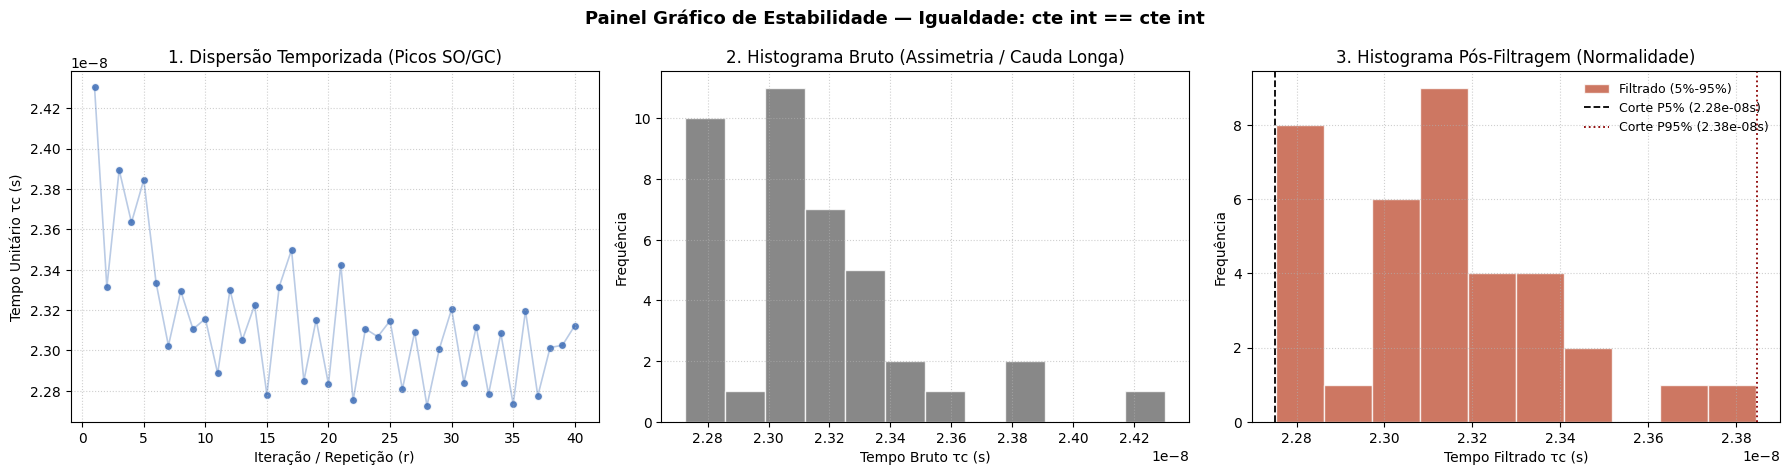

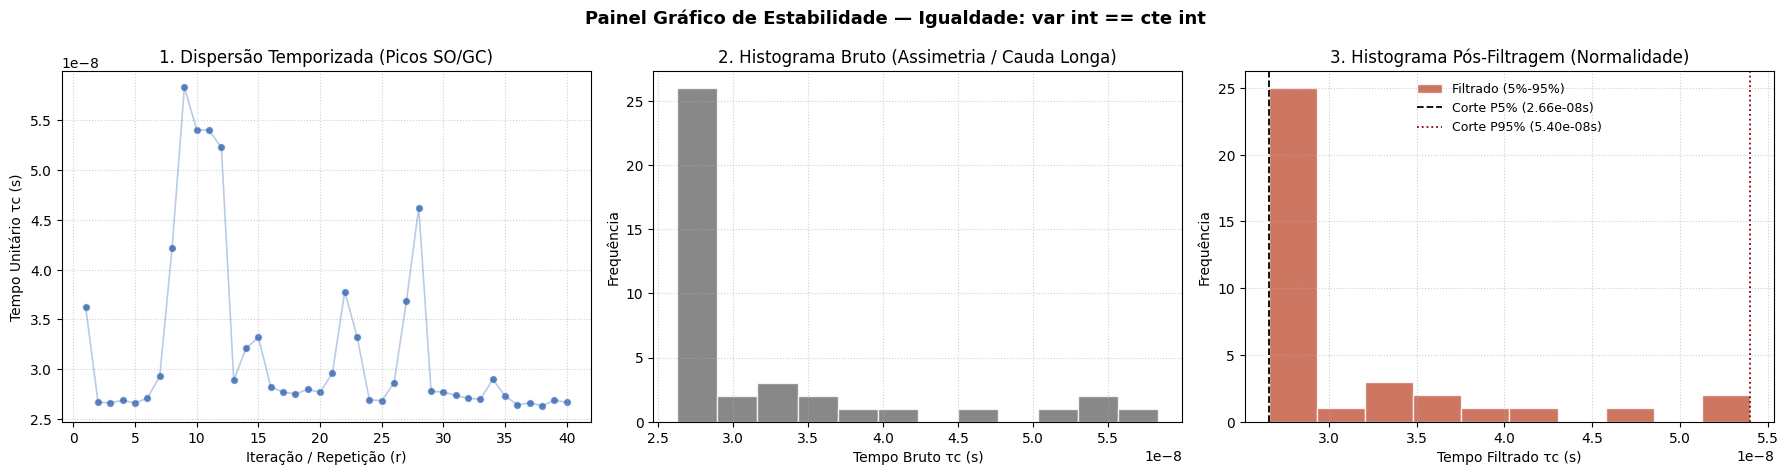

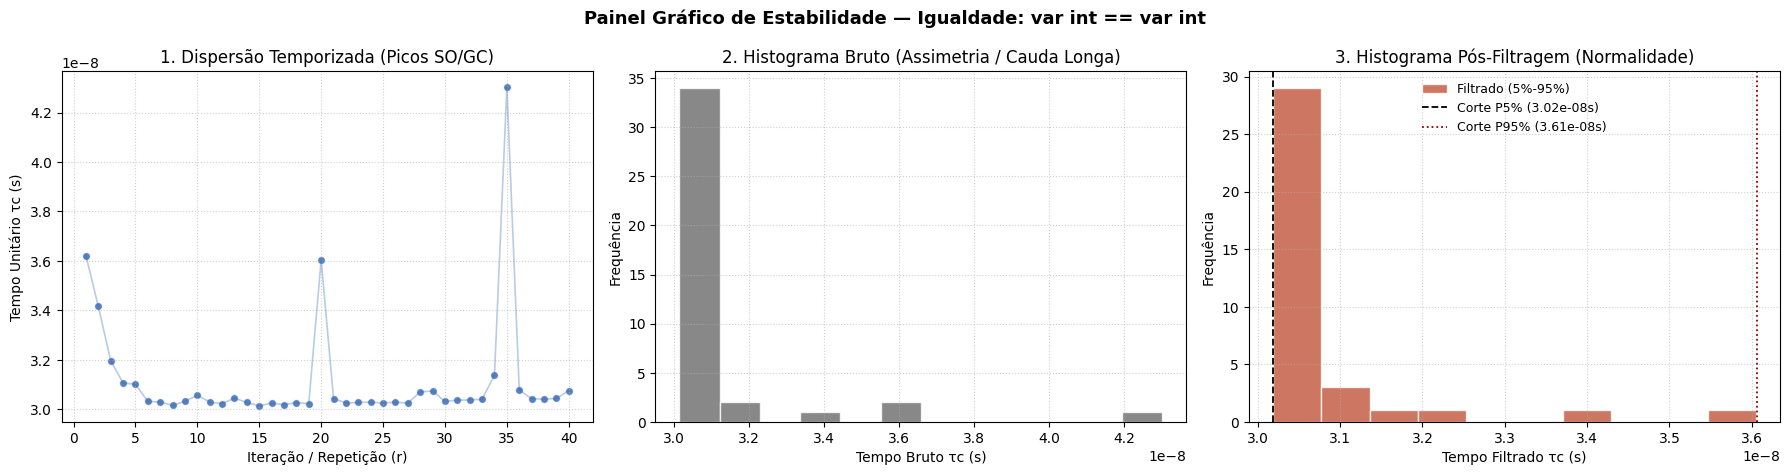

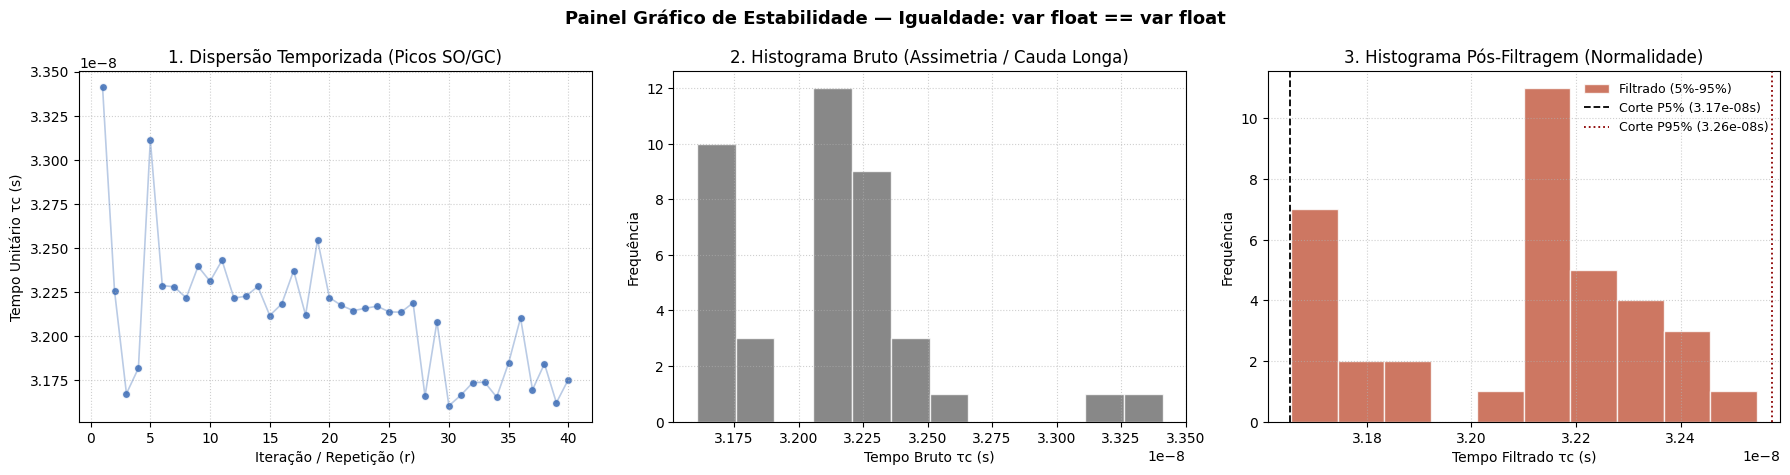

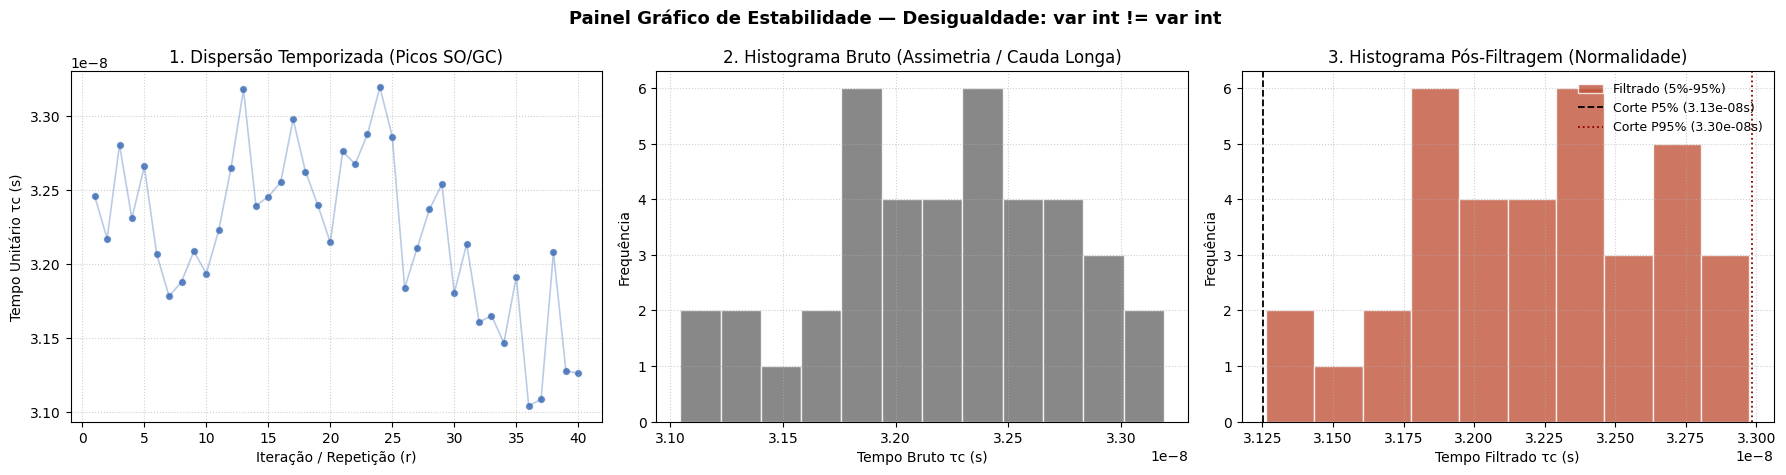

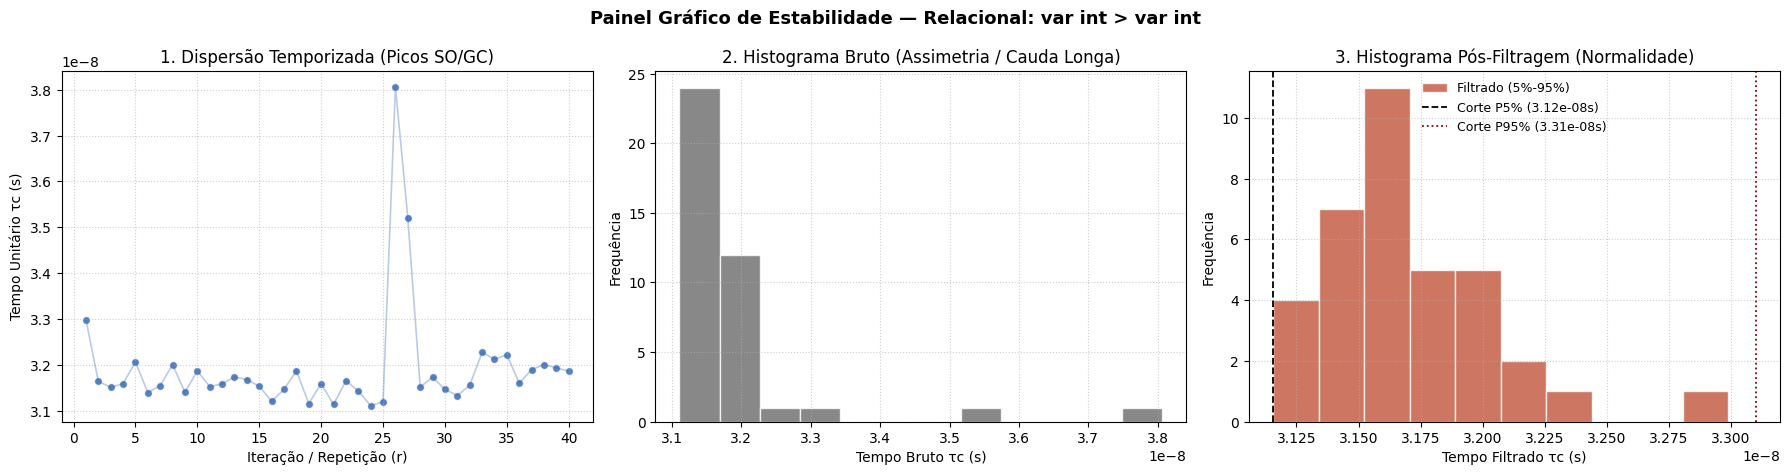

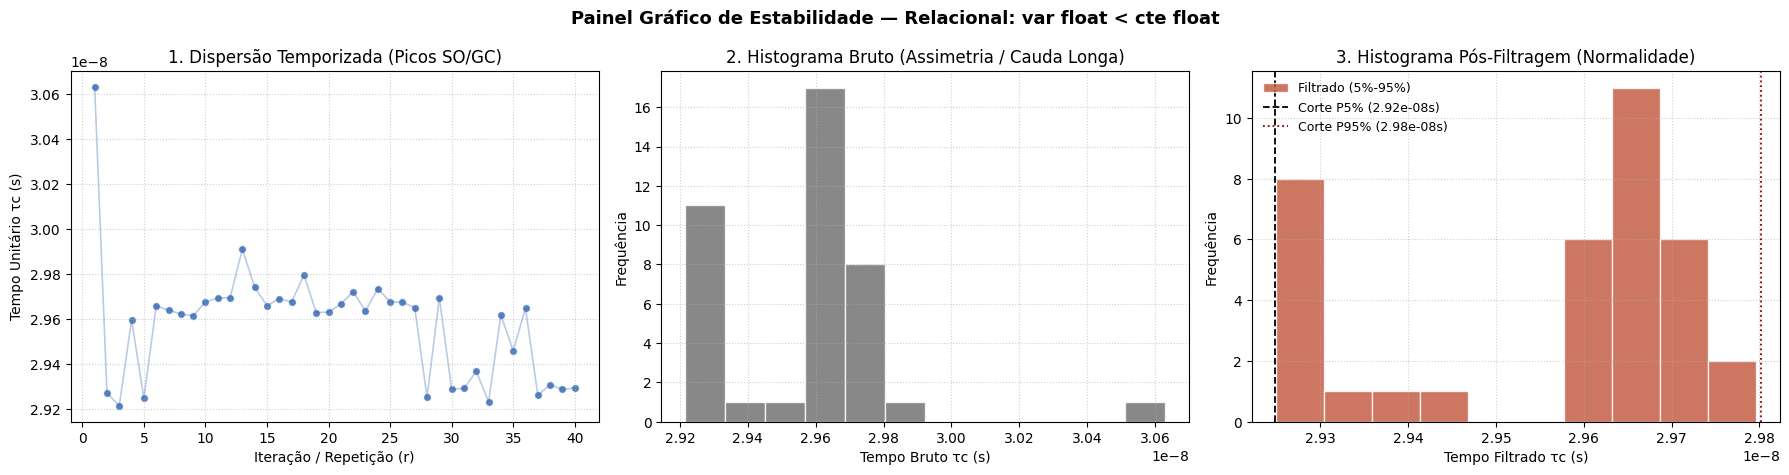

In [2]:
# ==============================================================================
# 2. MEDIÇÃO DIRETA IN-LINE (SEM FUNÇÕES) E GERAÇÃO DOS GRÁFICOS POR COMPARAÇÃO
# ==============================================================================

# Estruturas para armazenar os tempos e estatísticas
tempos_brutos = {}
tempos_filtrados = {}
cortes_percentil = {}
tabela_resultados = []
reps = np.arange(1, R + 1)

# Função auxiliar apenas para plotar o painel visual de 3 gráficos para cada operação
def plot_painel(nome_op, raw, fil, p5, p95):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    fig.suptitle(f"Painel Gráfico de Estabilidade — {nome_op}", fontsize=13, fontweight="bold")
    
    # 1. Dispersão Temporizada (r vs Tempo)
    axes[0].scatter(reps, raw, color="#3B6BB5", s=35, alpha=0.85, edgecolor="white")
    axes[0].plot(reps, raw, color="#3B6BB5", alpha=0.35, lw=1.2)
    axes[0].set_xlabel("Iteração / Repetição (r)")
    axes[0].set_ylabel("Tempo Unitário τc (s)")
    axes[0].set_title("1. Dispersão Temporizada (Picos SO/GC)")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    
    # 2. Histograma de Dados Brutos
    axes[1].hist(raw, bins=12, color="#6B6B6B", edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("Tempo Bruto τc (s)")
    axes[1].set_ylabel("Frequência")
    axes[1].set_title("2. Histograma Bruto (Assimetria / Cauda Longa)")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    
    # 3. Histograma Pós-Filtragem (Percentil 5% e 95%)
    axes[2].hist(fil, bins=10, color="#C1553B", edgecolor="white", alpha=0.8, label="Filtrado (5%-95%)")
    axes[2].axvline(p5, color="black", ls="--", lw=1.3, label=f"Corte P5% ({p5:.2e}s)")
    axes[2].axvline(p95, color="darkred", ls=":", lw=1.3, label=f"Corte P95% ({p95:.2e}s)")
    axes[2].set_xlabel("Tempo Filtrado τc (s)")
    axes[2].set_ylabel("Frequência")
    axes[2].set_title("3. Histograma Pós-Filtragem (Normalidade)")
    axes[2].legend(frameon=False, fontsize=9)
    axes[2].grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def processar_estatisticas(nome_op, times_list):
    raw = np.array(times_list)
    tempos_brutos[nome_op] = raw
    
    mu_b = np.mean(raw)
    sigma_b = np.std(raw, ddof=1)
    cv_b = sigma_b / mu_b
    
    # Filtro de Percentil 5% e 95%
    p5 = np.percentile(raw, 5)
    p95 = np.percentile(raw, 95)
    cortes_percentil[nome_op] = (p5, p95)
    
    fil = raw[(raw >= p5) & (raw <= p95)]
    tempos_filtrados[nome_op] = fil
    
    mu_f = np.mean(fil)
    sigma_f = np.std(fil, ddof=1)
    cv_f = sigma_f / mu_f
    
    tabela_resultados.append({
        "Operação e Tipagem Exata": nome_op,
        "µbruta (s)": f"{mu_b:.4e}",
        "σbruta (s)": f"{sigma_b:.4e}",
        "CVbruto": f"{cv_b:.4f}",
        "µfil(τc) (s)": f"{mu_f:.4e}",
        "σfil (s)": f"{sigma_f:.4e}",
        "CVfil": f"{cv_f:.4f}",
        "< 0.15": "Sim" if cv_f < 0.15 else "Não"
    })
    
    plot_painel(nome_op, raw, fil, p5, p95)

# ------------------------------------------------------------------------------
# 1. Igualdade: cte int == cte int
# ------------------------------------------------------------------------------
nome_op1 = "Igualdade: cte int == cte int"
t_op1 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        1 == 1
    t1 = time.perf_counter()
    t_op1.append((t1 - t0) / N)
processar_estatisticas(nome_op1, t_op1)

# ------------------------------------------------------------------------------
# 2. Igualdade: var int == cte int
# ------------------------------------------------------------------------------
nome_op2 = "Igualdade: var int == cte int"
t_op2 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 == 42
    t1 = time.perf_counter()
    t_op2.append((t1 - t0) / N)
processar_estatisticas(nome_op2, t_op2)

# ------------------------------------------------------------------------------
# 3. Igualdade: var int == var int
# ------------------------------------------------------------------------------
nome_op3 = "Igualdade: var int == var int"
t_op3 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 == v_int2
    t1 = time.perf_counter()
    t_op3.append((t1 - t0) / N)
processar_estatisticas(nome_op3, t_op3)

# ------------------------------------------------------------------------------
# 4. Igualdade: var float == var float
# ------------------------------------------------------------------------------
nome_op4 = "Igualdade: var float == var float"
t_op4 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 == v_flt2
    t1 = time.perf_counter()
    t_op4.append((t1 - t0) / N)
processar_estatisticas(nome_op4, t_op4)

# ------------------------------------------------------------------------------
# 5. Desigualdade: var int != var int
# ------------------------------------------------------------------------------
nome_op5 = "Desigualdade: var int != var int"
t_op5 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 != v_int3
    t1 = time.perf_counter()
    t_op5.append((t1 - t0) / N)
processar_estatisticas(nome_op5, t_op5)

# ------------------------------------------------------------------------------
# 6. Relacional: var int > var int
# ------------------------------------------------------------------------------
nome_op6 = "Relacional: var int > var int"
t_op6 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int3 > v_int1
    t1 = time.perf_counter()
    t_op6.append((t1 - t0) / N)
processar_estatisticas(nome_op6, t_op6)

# ------------------------------------------------------------------------------
# 7. Relacional: var float < cte float
# ------------------------------------------------------------------------------
nome_op7 = "Relacional: var float < cte float"
t_op7 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt3 < 3.14159
    t1 = time.perf_counter()
    t_op7.append((t1 - t0) / N)
processar_estatisticas(nome_op7, t_op7)


In [3]:
# ==============================================================================
# 3. MATRIZ FINAL DE CALIBRAÇÃO HOMOLOGADA (τc)
# ==============================================================================

df_tau_c = pd.DataFrame(tabela_resultados)
print("\n" + "="*80)
print("4.2. CUSTO DE COMPARAÇÕES (τc) - HOMOLOGAÇÃO (CV < 0.15)")
print("="*80)
display(df_tau_c)



4.2. CUSTO DE COMPARAÇÕES (τc) - HOMOLOGAÇÃO (CV < 0.15)


,Operação e Tipagem Exata,µbruta (s),σbruta (s),CVbruto,µfil(τc) (s),σfil (s),CVfil,< 0.15
0,Igualdade: cte int == cte int,2.3146e-08,3.3722e-10,0.0146,2.3116e-08,2.4825e-10,0.0107,Sim
1,Igualdade: var int == cte int,3.2133e-08,8.8516e-09,0.2755,3.1117e-08,7.1405e-09,0.2295,Não
2,Igualdade: var int == var int,3.1166e-08,2.3805e-09,0.0764,3.0752e-08,1.1545e-09,0.0375,Sim
3,Igualdade: var float == var float,3.2115e-08,3.7384e-10,0.0116,3.2079e-08,2.5231e-10,0.0079,Sim
4,Desigualdade: var int != var int,3.2207e-08,5.4675e-10,0.0170,3.2216e-08,4.5169e-10,0.0140,Sim
5,Relacional: var int > var int,3.1917e-08,1.1988e-09,0.0376,3.1699e-08,3.5688e-10,0.0113,Sim
6,Relacional: var float < cte float,2.9577e-08,2.5795e-10,0.0087,2.9558e-08,1.7829e-10,0.0060,Sim
